In [ ]:
import pandas as pd
import scanpy as sc
import os

# Read in the Hamming distance matrix
df = pd.read_csv("g2_hamming_distance_10%_VMRS.tsv", sep="\t", index_col=0)

# Read in the meta csv file
meta = pd.read_csv("humainbrain_meta.csv")  

# Only retain the cells that appear in the matrix.
meta = meta[meta["cell_id"].isin(df.index)]

# Ensure consistency in the sequence.
meta = meta.set_index("cell_id").loc[df.index]

# Convert to AnnData
adata = sc.AnnData(df.values)
adata.obs = meta

# Add the index name (which Scanpy will use)
adata.obs_names = df.index
adata.var_names = df.columns

print(adata)

AnnData object with n_obs × n_vars = 2901 × 2901
    obs: 'MajorType', 'SubType'


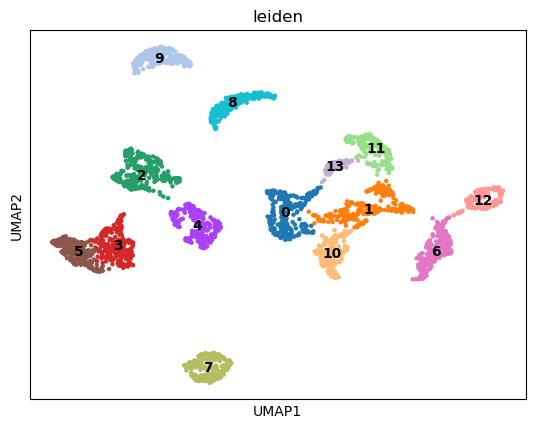

In [8]:
# Normalize (optional, since this is a similarity matrix, no log is needed here)
sc.pp.scale(adata)

# PCA
sc.tl.pca(adata, svd_solver='arpack')

# Neighbors
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

# UMAP
sc.tl.umap(adata)

sc.tl.leiden(adata, resolution=0.4)

# Visualization, color-coded by leiden
sc.pl.umap(adata, color=["leiden"], legend_loc="on data", frameon=True)

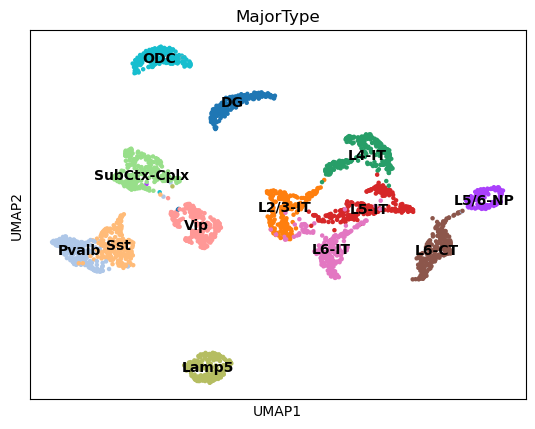

In [9]:
# Visualization, color-coded by MajorType
sc.pl.umap(adata, color=["MajorType"], legend_loc="on data", frameon=True)

In [ ]:
# ==========Export the cell IDs for each MajorType==========
#When making subsequent annotations, this will be utilized.

groups = adata.obs.groupby("MajorType").groups

# output directory
outdir = "~/anno/group1"

os.makedirs(outdir, exist_ok=True)

for major, idx in groups.items():
    # Replace the illegal characters in the file name
    safe_major = major.replace("/", "_").replace(" ", "_")
    fname = os.path.join(outdir, f"{safe_major}_cells.txt")
    with open(fname, "w") as f:
        for cell in idx:
            f.write(cell + "\n")

print(f"The cell IDs of each MajorType have been saved to {outdir}/")